In [ ]:
# 3 - modeling

# The purpose of this notebook is to print out the loss curve for the current best model

In [1]:
"""This file contains the full model pipeline as well as
instructions on how to add in new data."""

import sys
import os
sys.path.append(os.path.abspath("."))

from src.data import load_images_from_metadata, filter_images
from src.build_metadata import load_metadata
from src.model import train_and_evaluate, export_onnx
from src.evaluation import evaluate_model, predict_from_image_path


# Step 1: Build metadata.csv from images in the local data folders.
# If you are using the original shared dataset, copy the folders
# (data, data_new, data_new_2, data_test) into this project root first.
load_metadata(
    data_base_dir="data",
    new_data_base_dir="data_new",
    new_data_2_base_dir="data_new_2",
    output_file="metadata.csv",
)

Applied human ratings to 851 DD rows.
Saved metadata to .\metadata.csv
Combined records: 1337


,LevelingScore,Person,DateCollected,ImageType,GSCamera,PanelID,State,FilePath
0,1.3,None,None,DD,None,25-130,raw,data\raw\1\Leveling-1_GS-25-130_0degrees (1).png
1,1.3,None,None,DD,None,25-130,raw,data\raw\1\Leveling-1_GS-25-130_0degrees (2).png
2,1.3,None,None,DD,None,25-130,raw,data\raw\1\Leveling-1_GS-25-130_0degrees (3).png
3,1.3,None,None,DD,None,25-130,raw,data\raw\1\Leveling-1_GS-25-130_0degrees (4).png
4,1.3,None,None,DD,None,25-130,raw,data\raw\1\Leveling-1_GS-25-130_0degrees (5).png
...,...,...,...,...,...,...,...,...
1332,10.0,Nicole,7.9.2026,DD,2BDR-9F02,25-154,raw,data_new_2\10\{leveling-10}_P{Nicole}_D{7.9.20...
1333,10.0,Nicole,7.9.2026,DD,2BDR-9F02,25-154,raw,data_new_2\10\{leveling-10}_P{Nicole}_D{7.9.20...
1334,10.0,Nicole,7.9.2026,DD,2BDR-9F02,25-154,flat,data_new_2\10\{leveling-10}_P{Nicole}_D{7.9.20...
1335,10.0,Nicole,7.9.2026,DD,2BDR-9F02,25-154,flat,data_new_2\10\{leveling-10}_P{Nicole}_D{7.9.20...


In [2]:
# Step 2: Load images from metadata.csv.
# crop_fraction=0.4 keeps the center region by trimming edges before training.
data = load_images_from_metadata("metadata.csv", crop_fraction=0.4, use_cv2=True)

# Step 3: Filter the dataset used for training/evaluation.
# Standards are currently limited to specific collection dates due to
# known collection issues; adjust these filters if your dataset is different.
data_standards = filter_images(
    data,
    ImageType="STD",
    State="flat",
    DateCollected=["6.2.2026", "6.3.2026", "6.5.2026", "6.8.2026"],
)
data_real_paint = filter_images(data, ImageType="DD", State="flat")

Loaded 1337 images (cropping=ON, median_norm=OFF, backend=cv2)
Filtered down to 177 images
Filtered down to 430 images


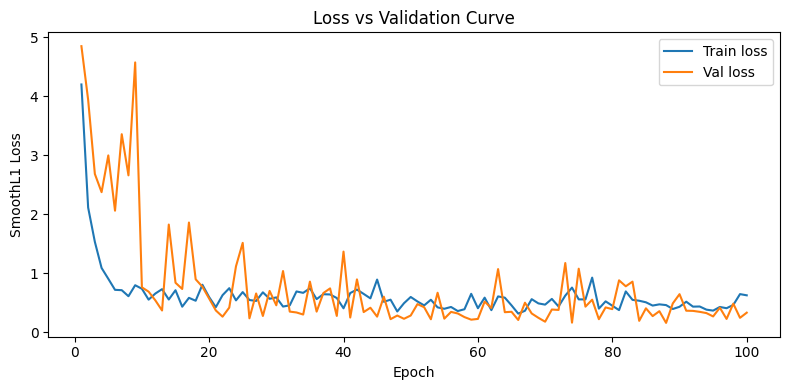

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, random_split
from src.model import (
    WaveletCNNRegressor, TensorListDataset, prepare_tensors,
    make_transforms, weighted_sampler_from_y, make_optimizer,
    make_loss, DEFAULT_PARAMS, DEVICE,
)

params = DEFAULT_PARAMS
img_size = int(params["img_size"])
epochs = 100
run_seed = 3

torch.manual_seed(run_seed)
np.random.seed(run_seed)

X, y, _ = prepare_tensors(data_standards, img_size=(img_size, img_size))
train_tf, val_tf = make_transforms(img_size, int(params["rotation_deg"]), float(params["crop_scale"]))

# 80/20 train/val split on standards
n_train = int(0.8 * len(X))
n_val = len(X) - n_train
indices = torch.randperm(len(X), generator=torch.Generator().manual_seed(run_seed)).tolist()
train_idx, val_idx = indices[:n_train], indices[n_train:]

X_train = [X[i] for i in train_idx]; y_train = y[train_idx]
X_val   = [X[i] for i in val_idx];   y_val   = y[val_idx]

train_ds = TensorListDataset(X_train, y_train, transform=train_tf)
val_ds   = TensorListDataset(X_val,   y_val,   transform=val_tf)

sampler = weighted_sampler_from_y(y_train, seed=run_seed)
train_loader = DataLoader(train_ds, batch_size=int(params["batch_size"]), sampler=sampler)
val_loader   = DataLoader(val_ds,   batch_size=int(params["batch_size"]), shuffle=False)

model = WaveletCNNRegressor(
    num_blocks=int(params["num_blocks"]),
    base_channels=int(params["base_channels"]),
    hidden_dim=int(params["hidden_dim"]),
    dropout=float(params["dropout"]),
    use_batchnorm=bool(params["use_batchnorm"]),
).to(DEVICE)

optimizer = make_optimizer(params["optimizer"], model.parameters(), float(params["lr"]), float(params["weight_decay"]))
criterion = make_loss(params["loss"])

train_losses, val_losses = [], []

for epoch in range(epochs):
    model.train()
    running, n = 0.0, 0
    for imgs, lbls in train_loader:
        imgs, lbls = imgs.to(DEVICE), lbls.to(DEVICE)
        optimizer.zero_grad()
        loss = criterion(model(imgs), lbls)
        loss.backward()
        optimizer.step()
        running += loss.item() * imgs.size(0)
        n += imgs.size(0)
    train_losses.append(running / n)

    model.eval()
    running, n = 0.0, 0
    with torch.no_grad():
        for imgs, lbls in val_loader:
            imgs, lbls = imgs.to(DEVICE), lbls.to(DEVICE)
            loss = criterion(model(imgs), lbls)
            running += loss.item() * imgs.size(0)
            n += imgs.size(0)
    val_losses.append(running / n)

plt.figure(figsize=(8, 4))
plt.plot(range(1, epochs + 1), train_losses, label="Train loss")
plt.plot(range(1, epochs + 1), val_losses,   label="Val loss")
plt.xlabel("Epoch")
plt.ylabel("SmoothL1 Loss")
plt.title("Loss vs Validation Curve")
plt.legend()
plt.tight_layout()
plt.show()